# CNN with Callbacks - Fashion-MNIST


## data : https://www.kaggle.com/datasets/zalando-research/fashionmnist

### الداتا موجودة أصلا جوا keras

In [1]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import datasets, layers, models
import numpy as np

In [2]:
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
y_train_labels = y_train.copy()
y_test_labels = y_test.copy()

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)
print('x_train shape: ',x_train.shape)
print('x_train test: ',x_test.shape)

x_train shape:  (60000, 28, 28, 1)
x_train test:  (10000, 28, 28, 1)


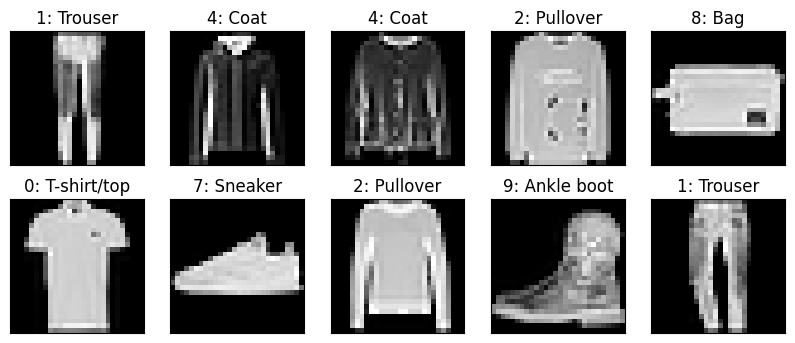

In [4]:
import matplotlib.pyplot as plt
import numpy as np
idx = [3, 6, 25, 46, 58, 85, 93, 99, 108, 133]
clsmap = {
    0:'T-shirt/top',
    1:'Trouser',
    2:'Pullover',
    3:'Dress',
    4: 'Coat',
    5: 'Sandal',
    6:'Shirt',
    7:'Sneaker',
    8:'Bag',
    9:'Ankle boot'
}
plt.figure(figsize = (10,4))
for i, (img, y) in enumerate(zip(x_test[idx].reshape(10,28,28), y_test_labels[idx])):
  plt.subplot(2,5,i+1)
  plt.imshow(img,cmap='gray')
  plt.xticks([])
  plt.yticks([])
  plt.title(str(y) + ": "+ clsmap[int(y)])
plt.show()

In [5]:
model1 = models.Sequential()

In [6]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop

inpt_dim = (28,28,1)
inpt_img= Input(shape=inpt_dim)

c11 = Conv2D(64,(9,9), strides=(2,2), input_shape = inpt_dim, activation='relu')(inpt_img)

p12 = MaxPooling2D(pool_size = (2,2))(c11)
bn13 = BatchNormalization()(p12)


c14 = Conv2D(128,(3,3), strides=(1,1), activation='relu')(bn13)
p15 = MaxPooling2D(pool_size = (2,2))(c14)
bn16 = BatchNormalization()(p15)


f17 = Flatten()(bn16)

do18 = Dropout(0.5)(f17)
d19 = Dense(units = 256,activation = 'relu')(do18)
do110 = Dropout(0.2)(d19)
d111 = Dense(units = 64, activation = 'relu')(do110)
do112 = Dropout(0.1)(d111)
output= Dense(units = 10, activation='sigmoid')(do112)

classifier = Model(inpt_img, output)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
opt = RMSprop(learning_rate=0.001)
classifier.compile(optimizer=opt, loss='binary_crossentropy',metrics=['accuracy'])
print(classifier.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 10, 10, 64)     │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 1, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,994 (507.79 KB)

 Trainable params: 129,610 (506.29 KB)

 Non-trainable params: 384 (1.50 KB)

None


In [8]:

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10,
                              min_delta=1e-4, mode='min', verbose=1)

stop_alg = EarlyStopping(monitor='val_loss', patience=35,
                         restore_best_weights=True, verbose=1)

checkpoint_filepath = 'cnn_model.h5'
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

hist = classifier.fit(x_train, y_train, batch_size=512, epochs=10,
                   callbacks=[stop_alg, reduce_lr, model_checkpoint], shuffle=True,
                   validation_data=(x_test, y_test))

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5942 - loss: 0.2417

118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 206ms/step - accuracy: 0.7071 - loss: 0.1556 - val_accuracy: 0.1332 - val_loss: 0.3549 - learning_rate: 0.0010
Epoch 2/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8031 - loss: 0.0977

118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 179ms/step - accuracy: 0.8108 - loss: 0.0942 - val_accuracy: 0.3482 - val_loss: 0.3155 - learning_rate: 0.0010
Epoch 3/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8294 - loss: 0.0847

118/118 ━━━━━━━━━━━━━━━━━━━━ 41s 180ms/step - accuracy: 0.8345 - loss: 0.0831 - val_accuracy: 0.5306 - val_loss: 0.1984 - learning_rate: 0.0010
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8446 - loss: 0.0773

118/118 ━━━━━━━━━━━━━━━━━━━━ 42s 193ms/step - accuracy: 0.8475 - loss: 0.0764 - val_accuracy: 0.7912 - val_loss: 0.0991 - learning_rate: 0.0010
Epoch 5/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8534 - loss: 0.0724

118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 178ms/step - accuracy: 0.8558 - loss: 0.0714 - val_accuracy: 0.8111 - val_loss: 0.0904 - learning_rate: 0.0010
Epoch 6/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.8603 - loss: 0.0691

118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 192ms/step - accuracy: 0.8619 - loss: 0.0683 - val_accuracy: 0.8572 - val_loss: 0.0696 - learning_rate: 0.0010
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 40s 186ms/step - accuracy: 0.8676 - loss: 0.0659 - val_accuracy: 0.8086 - val_loss: 0.0809 - learning_rate: 0.0010
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 22s 184ms/step - accuracy: 0.8708 - loss: 0.0638 - val_accuracy: 0.8445 - val_loss: 0.0772 - learning_rate: 0.0010
Epoch 9/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8736 - loss: 0.0619

118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 177ms/step - accuracy: 0.8750 - loss: 0.0614 - val_accuracy: 0.8659 - val_loss: 0.0655 - learning_rate: 0.0010
Epoch 10/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 192ms/step - accuracy: 0.8783 - loss: 0.0605 - val_accuracy: 0.8061 - val_loss: 0.1016 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 9.


In [9]:
classifier.save_weights("cnn1.weights.h5")

In [10]:
classifier.load_weights('cnn1.weights.h5')

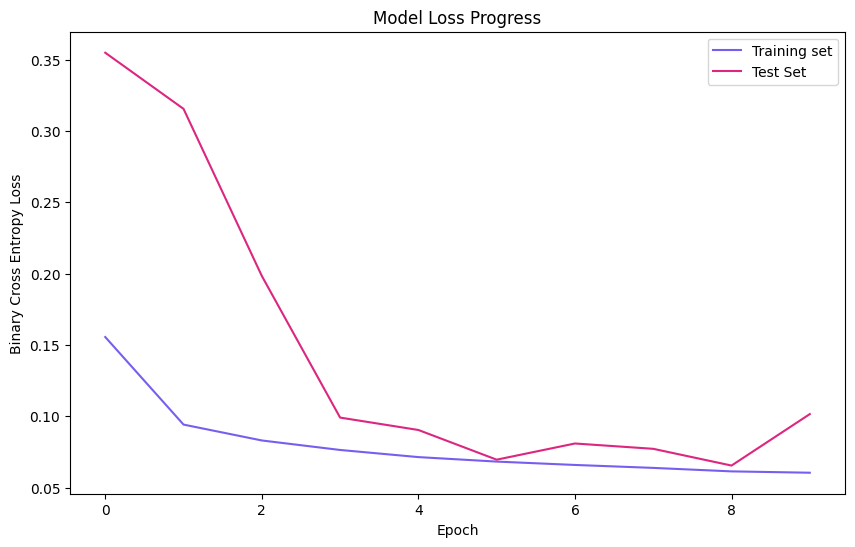

In [11]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,6))
plt.plot(hist.history['loss'], color='#785ef0')
plt.plot(hist.history['val_loss'], color='#dc267f')
plt.title('Model Loss Progress')
plt.ylabel('Binary Cross Entropy Loss')
plt.xlabel('Epoch')
plt.legend(['Training set','Test Set'], loc='upper right')
plt.show()

In [12]:
# Reload the best saved weights and recompile for evaluation
classifier.load_weights('cnn1.weights.h5')
classifier.compile(optimizer=RMSprop(), loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt
import numpy as np

y_hat = classifier.predict(x_test)
y_pred = np.argmax(y_hat, axis=1)

print(classification_report(np.argmax(y_test,axis=1), np.argmax(y_hat, axis=1), labels=[0,1,2,3,4,5,6,7,8,9]))

cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(y_hat, axis=1), labels=[0,1,2,3,4,5,6,7,8,9])
print(cm)

ber = 1-balanced_accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hat, axis=1))
print('BER', ber)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       0.77      0.87      0.82      1000
           1       1.00      0.96      0.98      1000
           2       0.74      0.85      0.79      1000
           3       0.88      0.88      0.88      1000
           4       0.71      0.85      0.78      1000
           5       0.97      0.96      0.97      1000
           6       0.72      0.40      0.52      1000
           7       0.94      0.96      0.95      1000
           8       0.96      0.97      0.97      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.86     10000
weighted avg       0.87      0.87      0.86     10000

[[872   0  35  19   9   1  55   0   9   0]
 [  3 958   2  27   3   0   5   0   2   0]
 [ 13   0 846  12  99   0  26   0   4   0]
 [ 27   0  22 881  43   0  25   0   2   0]
 [  1   0  79  26 852   0  4

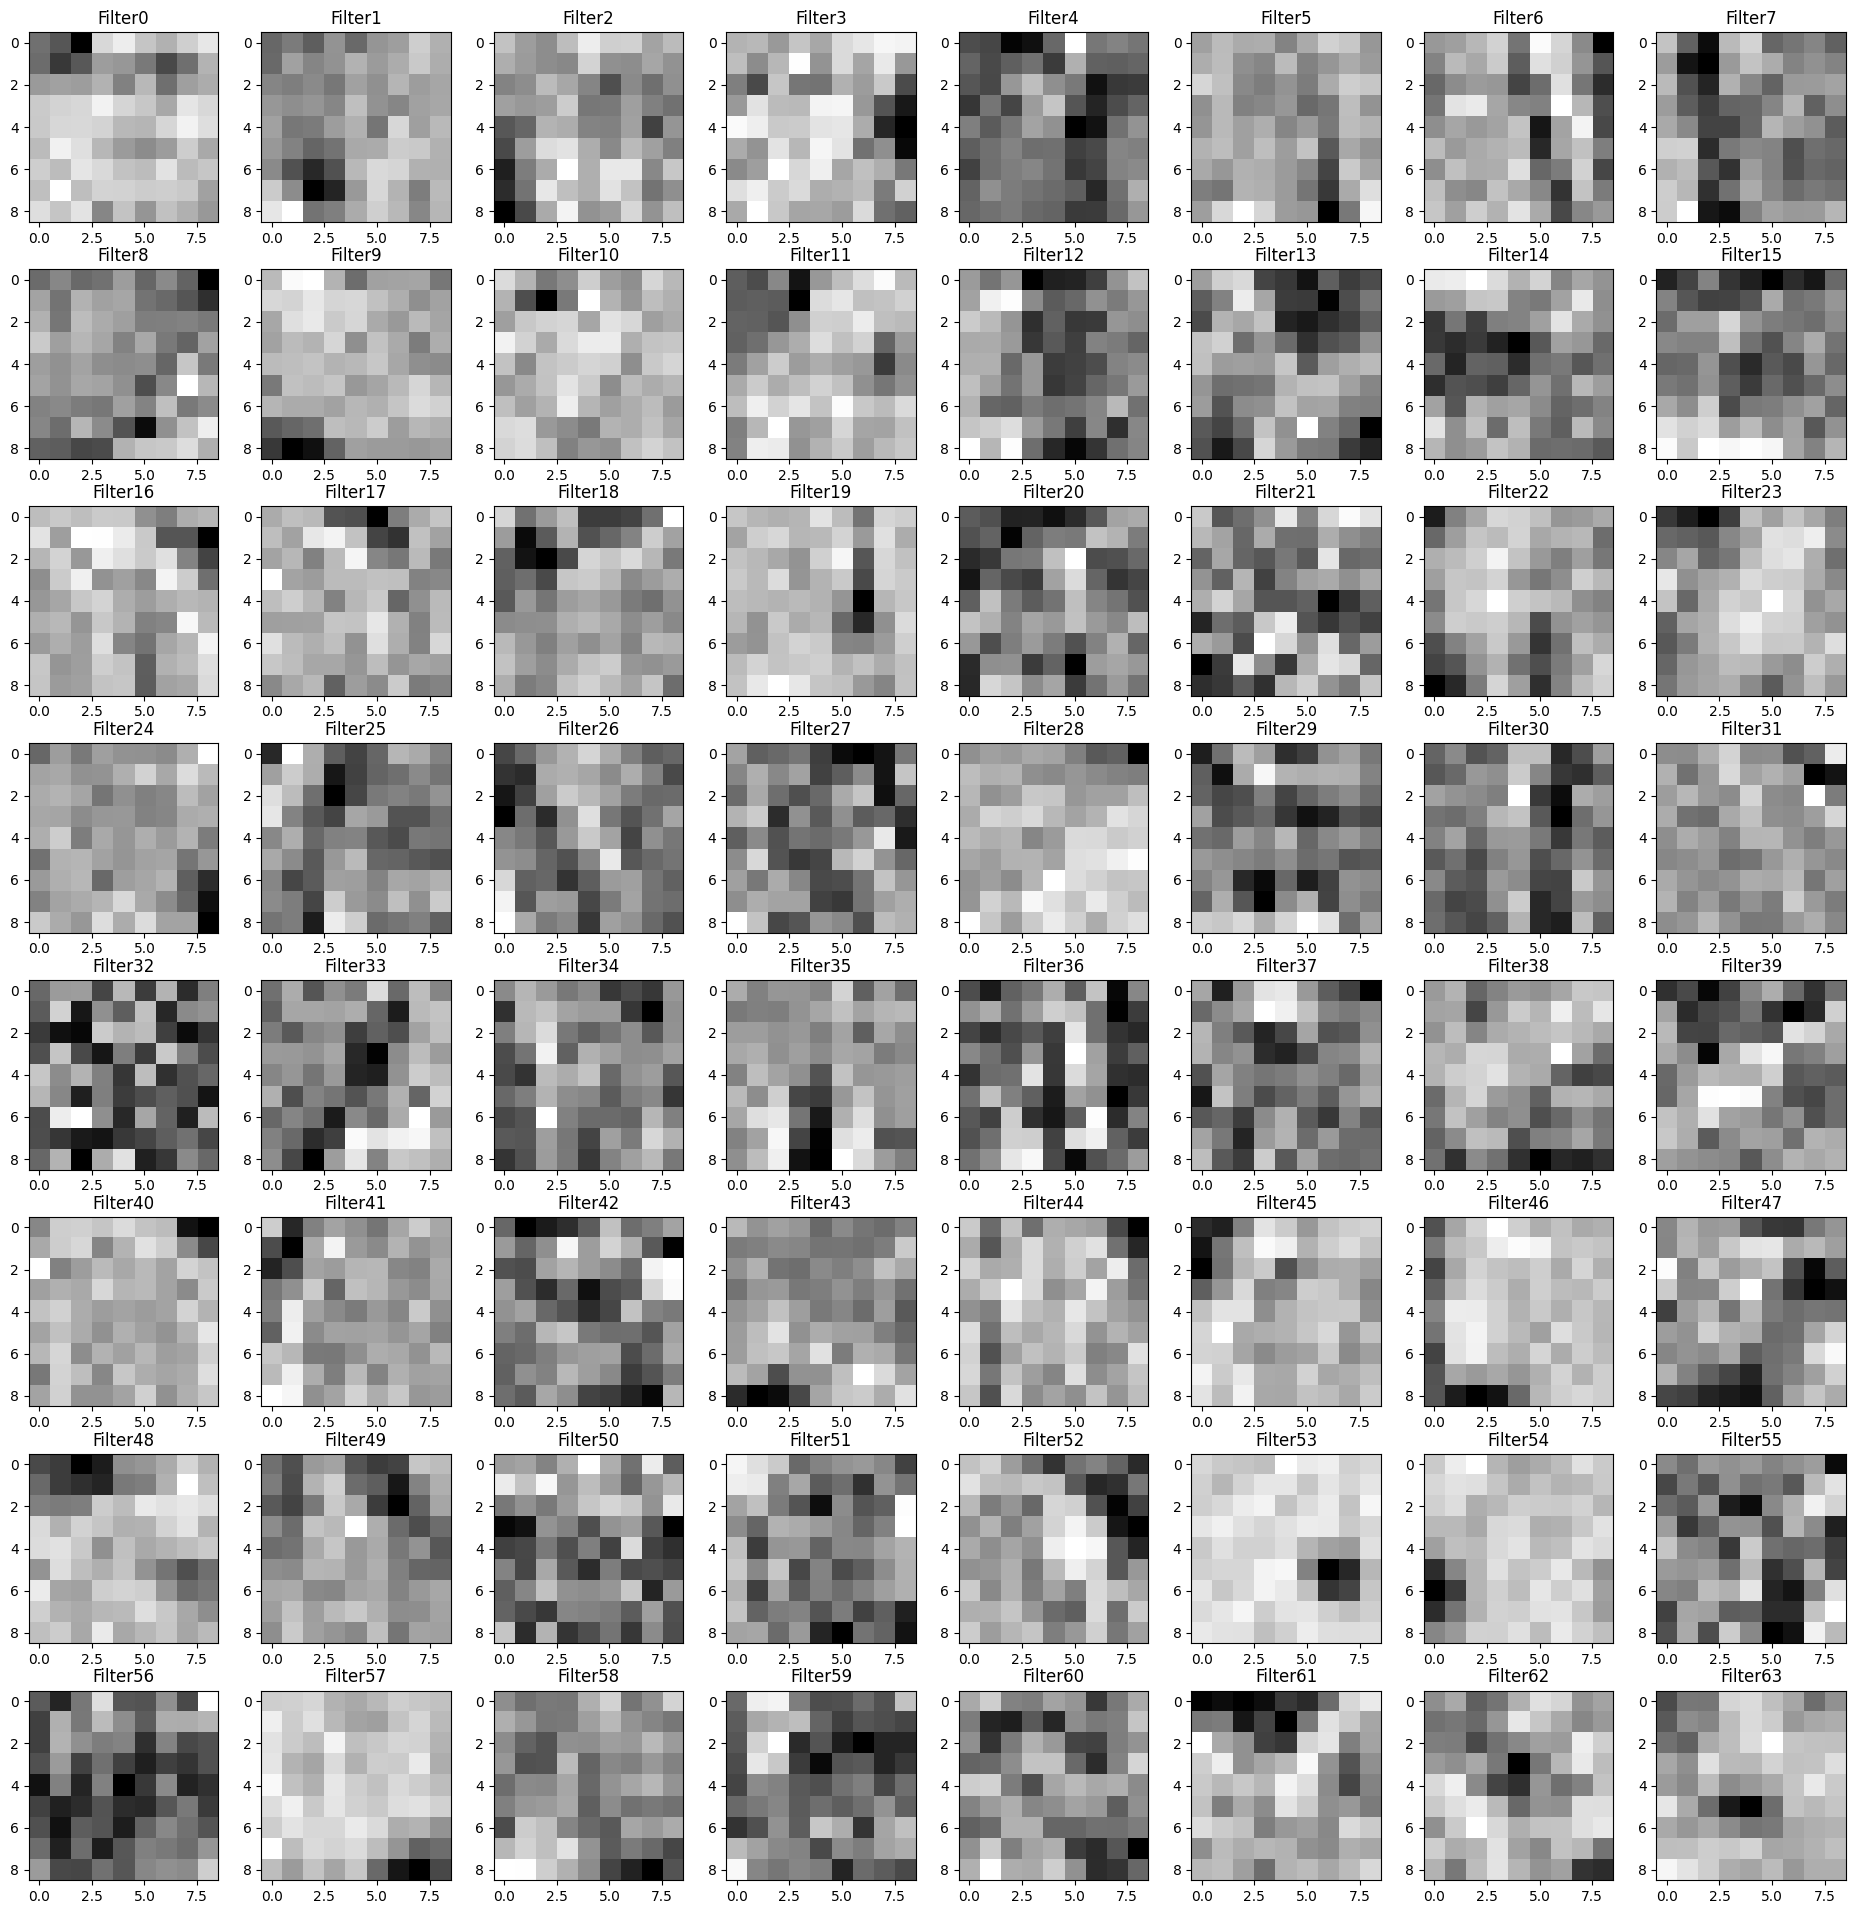

In [14]:
from sklearn.preprocessing import MinMaxScaler
cnn11 = classifier.layers[1].name
w = classifier.get_layer(name=cnn11).get_weights()[0]
wshape = w.shape

scaler = MinMaxScaler()
scaler.fit(w.reshape(-1,1))
w = scaler.transform(w.reshape(-1,1))
w = w.reshape(wshape)

fig,axs = plt.subplots(8,8,figsize=(24,24))
fig.subplots_adjust(hspace=.25, wspace=.001)
axs = axs.ravel()
for i in range(w.shape[-1]):

  h=np.reshape(w[:,:,:,i],(9,9))
  axs[i].imshow(h, cmap='gray')
  axs[i].set_title('Filter'+str(i))

Gabor filters